# PART A – PROBLEM AND DATASET UNDERSTANDING

## Task A1 – Define the Problem

### Problem Statement

The dataset represents a **personalized diet recommendation** problem. Each observation contains demographic, physical, health, lifestyle, dietary and nutrition-related information for a patient, together with a recommended meal-plan category.

### Why is the problem important?

A personalized recommendation can be more appropriate than giving every person the same diet because people differ in age, body measurements, health indicators, activity, lifestyle, dietary habits and food preferences. From a machine-learning perspective, the dataset provides a practical classification problem with numerical and categorical inputs.

### Objective

The main analytical objective is to study the dataset, clean and transform it correctly, select useful input variables, avoid data leakage, and prepare a reliable ML-ready dataset for predicting the recommended meal-plan category.

### Target / Output Variable

The target is determined programmatically from the supplied dataset and is expected to be `Recommended_Meal_Plan`. The notebook verifies that column before using it.

### Problem Type

This is a **classification** problem because the output consists of discrete meal-plan categories rather than a continuous numerical value.

In [1]:
# Core imports
import os
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, f as f_dist
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_PATH = "/content/Personalized_Diet_Recommendations.csv"

# Colab-friendly fallback: upload the CSV if the expected path is not available.
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Expected CSV was not found. Please upload the dataset CSV.")
        uploaded = files.upload()
        csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
        if not csv_files:
            raise FileNotFoundError("No CSV file was uploaded.")
        DATA_PATH = "/content/" + csv_files[0]
    except ImportError:
        local_csv = [name for name in os.listdir(".") if name.lower().endswith(".csv")]
        if not local_csv:
            raise FileNotFoundError("Dataset CSV was not found.")
        DATA_PATH = local_csv[0]

print("Dataset path:", DATA_PATH)

Dataset path: /content/Personalized_Diet_Recommendations.csv


In [2]:
# Load the actual dataset
raw_df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", raw_df.shape)
display(raw_df.head())

Dataset loaded successfully.
Shape: (5000, 30)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,...,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,...,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,...,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,...,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,...,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet


## Task A2 – Describe the Dataset

The following cells calculate the dataset description directly from the actual CSV. No dataset-specific numerical result is hard-coded.

In [3]:
TARGET = "Recommended_Meal_Plan"
ID_COL = "Patient_ID"

if TARGET not in raw_df.columns:
    raise KeyError(f"Expected target '{TARGET}' was not found. Available columns: {raw_df.columns.tolist()}")

numeric_cols = raw_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = raw_df.select_dtypes(exclude=np.number).columns.tolist()

input_candidates = [c for c in raw_df.columns if c not in [TARGET, ID_COL]]
potential_target_derived = [
    c for c in ["Recommended_Calories", "Recommended_Protein", "Recommended_Carbs", "Recommended_Fats"]
    if c in raw_df.columns
]

predictive_input_cols = [c for c in input_candidates if c not in potential_target_derived]
predictive_numeric_cols = [c for c in predictive_input_cols if c in numeric_cols]
predictive_categorical_cols = [c for c in predictive_input_cols if c in categorical_cols]

print("Rows / observations:", len(raw_df))
print("Columns / features:", len(raw_df.columns))
print("Target:", TARGET)
print("Target classes:", sorted(raw_df[TARGET].dropna().astype(str).unique()))
print("\nNumerical columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categorical_cols)
print("\nIdentifier excluded from prediction:", ID_COL if ID_COL in raw_df.columns else "None")
print("Potential target-derived columns to evaluate for leakage:", potential_target_derived)

Rows / observations: 5000
Columns / features: 30
Target: Recommended_Meal_Plan
Target classes: ['Balanced Diet', 'High-Protein Diet', 'Low-Carb Diet', 'Low-Fat Diet']

Numerical columns:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Caloric_Intake', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Recommended_Calories', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats']

Categorical columns:
['Patient_ID', 'Gender', 'Chronic_Disease', 'Genetic_Risk_Factor', 'Allergies', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Meal_Plan']

Identifier excluded from prediction: Patient_ID
Potential target-derived columns to evaluate for leakage: ['Recommended_Calories', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats']


In [4]:
# Complete feature-description table
feature_descriptions = {
    "Patient_ID": "Unique patient identifier.",
    "Age": "Patient age in years.",
    "Gender": "Patient gender category.",
    "Height_cm": "Patient height in centimetres.",
    "Weight_kg": "Patient body weight in kilograms.",
    "BMI": "Body mass index.",
    "Chronic_Disease": "Recorded chronic-disease category.",
    "Blood_Pressure_Systolic": "Systolic blood-pressure measurement.",
    "Blood_Pressure_Diastolic": "Diastolic blood-pressure measurement.",
    "Cholesterol_Level": "Cholesterol measurement.",
    "Blood_Sugar_Level": "Blood-sugar measurement.",
    "Genetic_Risk_Factor": "Genetic risk indicator.",
    "Allergies": "Recorded allergy category.",
    "Daily_Steps": "Average daily steps.",
    "Exercise_Frequency": "Exercise frequency value.",
    "Sleep_Hours": "Average sleep duration in hours.",
    "Alcohol_Consumption": "Alcohol-consumption category.",
    "Smoking_Habit": "Smoking-habit category.",
    "Dietary_Habits": "Dietary-habit category.",
    "Caloric_Intake": "Current caloric intake.",
    "Protein_Intake": "Current protein intake.",
    "Carbohydrate_Intake": "Current carbohydrate intake.",
    "Fat_Intake": "Current fat intake.",
    "Preferred_Cuisine": "Preferred cuisine category.",
    "Food_Aversions": "Food-aversion category.",
    "Recommended_Calories": "Recommended calorie amount; evaluated as potentially target-derived.",
    "Recommended_Protein": "Recommended protein amount; evaluated as potentially target-derived.",
    "Recommended_Carbs": "Recommended carbohydrate amount; evaluated as potentially target-derived.",
    "Recommended_Fats": "Recommended fat amount; evaluated as potentially target-derived.",
    "Recommended_Meal_Plan": "Recommended meal-plan category; target/output."
}

rows = []
for c in raw_df.columns:
    dtype = "Numerical" if c in numeric_cols else "Categorical"
    if c == TARGET:
        io = "Output"
    elif c == ID_COL:
        io = "Excluded"
    elif c in potential_target_derived:
        io = "Excluded – Leakage Risk"
    else:
        io = "Input"
    rows.append([c, feature_descriptions.get(c, "Dataset feature."), dtype, io])

feature_table = pd.DataFrame(rows, columns=["Feature", "Description", "Data Type", "Input/Output"])
display(feature_table)

,Feature,Description,Data Type,Input/Output
0,Patient_ID,Unique patient identifier.,Categorical,Excluded
1,Age,Patient age in years.,Numerical,Input
2,Gender,Patient gender category.,Categorical,Input
3,Height_cm,Patient height in centimetres.,Numerical,Input
4,Weight_kg,Patient body weight in kilograms.,Numerical,Input
5,BMI,Body mass index.,Numerical,Input
6,Chronic_Disease,Recorded chronic-disease category.,Categorical,Input
7,Blood_Pressure_Systolic,Systolic blood-pressure measurement.,Numerical,Input
8,Blood_Pressure_Diastolic,Diastolic blood-pressure measurement.,Numerical,Input
9,Cholesterol_Level,Cholesterol measurement.,Numerical,Input


# PART B – INITIAL DATA EXPLORATION

## Task B1 – Inspect the Dataset

In [5]:
print("FIRST FEW RECORDS")
display(raw_df.head())

print("LAST FEW RECORDS")
display(raw_df.tail())

print("SHAPE")
print(raw_df.shape)

print("COLUMN NAMES")
for i, c in enumerate(raw_df.columns, start=1):
    print(i, c)

print("DATA TYPES")
display(raw_df.dtypes.rename("Data Type").to_frame())

print("NUMBER OF UNIQUE VALUES")
display(raw_df.nunique(dropna=True).sort_values().rename("Unique Values").to_frame())

print("MISSING VALUES")
display(raw_df.isna().sum().rename("Missing Values").to_frame())

print("DESCRIPTIVE STATISTICS")
display(raw_df.describe(include="all").T)

FIRST FEW RECORDS


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,...,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,...,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,...,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,...,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,...,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet


LAST FEW RECORDS


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
4995,P04996,42,Female,172,99,33.46,NaN,115,78,279,...,59,356,64,Western,Spicy,2869,70,402,68,Low-Carb Diet
4996,P04997,39,Female,155,61,25.39,NaN,110,97,258,...,119,164,112,Indian,NaN,1138,131,213,107,Low-Carb Diet
4997,P04998,48,Female,165,61,22.41,Diabetes,113,82,183,...,50,351,41,Mediterranean,Spicy,2893,40,380,34,Low-Carb Diet
4998,P04999,34,Other,151,82,35.96,Heart Disease,105,75,248,...,50,397,131,Asian,Salty,2201,56,367,128,Low-Fat Diet
4999,P05000,72,Other,173,98,32.74,NaN,121,105,292,...,184,234,67,Indian,NaN,2869,200,188,74,Low-Carb Diet


SHAPE
(5000, 30)
COLUMN NAMES
1 Patient_ID
2 Age
3 Gender
4 Height_cm
5 Weight_kg
6 BMI
7 Chronic_Disease
8 Blood_Pressure_Systolic
9 Blood_Pressure_Diastolic
10 Cholesterol_Level
11 Blood_Sugar_Level
12 Genetic_Risk_Factor
13 Allergies
14 Daily_Steps
15 Exercise_Frequency
16 Sleep_Hours
17 Alcohol_Consumption
18 Smoking_Habit
19 Dietary_Habits
20 Caloric_Intake
21 Protein_Intake
22 Carbohydrate_Intake
23 Fat_Intake
24 Preferred_Cuisine
25 Food_Aversions
26 Recommended_Calories
27 Recommended_Protein
28 Recommended_Carbs
29 Recommended_Fats
30 Recommended_Meal_Plan
DATA TYPES


...

,Unique Values
Genetic_Risk_Factor,2
Alcohol_Consumption,2
Smoking_Habit,2
Gender,3
Allergies,3
Food_Aversions,3
Dietary_Habits,4
Chronic_Disease,4
Preferred_Cuisine,4
Recommended_Meal_Plan,4


MISSING VALUES


,Missing Values
Patient_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Chronic_Disease,2043
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Level,0


DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5000,5000,P05000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,48.8056,17.906991,18.0,34.0,49.0,64.0,79.0
Gender,5000,3,Female,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,5000.0,NaN,NaN,NaN,174.244,14.229173,150.0,162.0,174.0,186.0,199.0
Weight_kg,5000.0,NaN,NaN,NaN,84.3662,20.18103,50.0,67.0,84.0,102.0,119.0
BMI,5000.0,NaN,NaN,NaN,28.353134,8.297745,12.63,21.85,27.64,33.8125,52.89
Chronic_Disease,2957,4,Diabetes,1019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood_Pressure_Systolic,5000.0,NaN,NaN,NaN,133.9824,26.216215,90.0,111.0,133.0,157.0,179.0
Blood_Pressure_Diastolic,5000.0,NaN,NaN,NaN,89.7358,17.283025,60.0,75.0,90.0,105.0,119.0
Cholesterol_Level,5000.0,NaN,NaN,NaN,224.2978,42.918923,150.0,187.0,224.0,261.0,299.0


### Interpretation

This inspection establishes the dataset structure before any transformation. In particular, it identifies which variables are numerical or categorical, where missing information exists, how many distinct values each feature contains, and the overall statistical ranges.

## Task B2 – Calculate Basic Statistics

### Formula / Logic

For a numerical variable:

- **Mean:** `x̄ = Σxi / n`
- **Range:** `Maximum − Minimum`
- **Population variance:** `σ² = Σ(xi − x̄)² / n`
- **Population standard deviation:** `σ = √σ²`

Median is the middle ordered value (or average of the two middle values), while mode is the most frequent value.

In [6]:
# From-scratch basic statistics functions

def manual_clean_numeric(values):
    return [float(v) for v in values if not pd.isna(v)]

def manual_mean(values):
    vals = manual_clean_numeric(values)
    return sum(vals) / len(vals)

def manual_median(values):
    vals = sorted(manual_clean_numeric(values))
    n = len(vals)
    if n == 0:
        return np.nan
    mid = n // 2
    if n % 2 == 1:
        return vals[mid]
    return (vals[mid - 1] + vals[mid]) / 2

def manual_mode(values):
    vals = [v for v in values if not pd.isna(v)]
    counts = {}
    for v in vals:
        counts[v] = counts.get(v, 0) + 1
    if not counts:
        return np.nan
    max_count = max(counts.values())
    modes = [k for k, v in counts.items() if v == max_count]
    return sorted(modes, key=str)[0]

def manual_variance(values):
    vals = manual_clean_numeric(values)
    mu = manual_mean(vals)
    return sum((x - mu) ** 2 for x in vals) / len(vals)

def manual_std(values):
    return math.sqrt(manual_variance(values))

def manual_min(values):
    return min(manual_clean_numeric(values))

def manual_max(values):
    return max(manual_clean_numeric(values))

def manual_range(values):
    return manual_max(values) - manual_min(values)

stats_rows = []
for c in numeric_cols:
    stats_rows.append([
        c, manual_min(raw_df[c]), manual_max(raw_df[c]), manual_mean(raw_df[c]),
        manual_median(raw_df[c]), manual_mode(raw_df[c]), manual_variance(raw_df[c]),
        manual_std(raw_df[c]), manual_range(raw_df[c])
    ])

manual_stats = pd.DataFrame(
    stats_rows,
    columns=["Feature", "Minimum", "Maximum", "Mean", "Median", "Mode", "Variance", "Std Dev", "Range"]
)
display(manual_stats.round(4))

,Feature,Minimum,Maximum,Mean,Median,Mode,Variance,Std Dev,Range
0,Age,18.00,79.00,48.8056,49.00,77.0,3.205962e+02,17.9052,61.00
1,Height_cm,150.00,199.00,174.2440,174.00,162.0,2.024289e+02,14.2277,49.00
2,Weight_kg,50.00,119.00,84.3662,84.00,64.0,4.071925e+02,20.1790,69.00
3,BMI,12.63,52.89,28.3531,27.64,20.2,6.883880e+01,8.2969,40.26
4,Blood_Pressure_Systolic,90.00,179.00,133.9824,133.00,104.0,6.871525e+02,26.2136,89.00
5,Blood_Pressure_Diastolic,60.00,119.00,89.7358,90.00,72.0,2.986432e+02,17.2813,59.00
6,Cholesterol_Level,150.00,299.00,224.2978,224.00,236.0,1.841666e+03,42.9146,149.00
7,Blood_Sugar_Level,70.00,249.00,159.3302,160.00,113.0,2.719019e+03,52.1442,179.00
8,Daily_Steps,2004.00,14997.00,8458.9228,8452.00,10429.0,1.400282e+07,3742.0346,12993.00
9,Exercise_Frequency,0.00,6.00,2.9782,3.00,0.0,4.004900e+00,2.0012,6.00


### Library Verification

The following cell verifies selected manual calculations using Pandas. The manual implementation remains the primary assignment implementation.

In [7]:
verification_rows = []
for c in numeric_cols[:5]:
    verification_rows.append([
        c,
        manual_mean(raw_df[c]), raw_df[c].mean(),
        manual_median(raw_df[c]), raw_df[c].median(),
        manual_variance(raw_df[c]), raw_df[c].var(ddof=0),
        manual_std(raw_df[c]), raw_df[c].std(ddof=0)
    ])

verification = pd.DataFrame(
    verification_rows,
    columns=["Feature", "Manual Mean", "Pandas Mean", "Manual Median", "Pandas Median",
             "Manual Variance", "Pandas Variance", "Manual Std", "Pandas Std"]
)
verification["Mean Difference"] = verification["Manual Mean"] - verification["Pandas Mean"]
verification["Variance Difference"] = verification["Manual Variance"] - verification["Pandas Variance"]
verification["Std Difference"] = verification["Manual Std"] - verification["Pandas Std"]
display(verification.round(10))

,Feature,Manual Mean,Pandas Mean,Manual Median,Pandas Median,Manual Variance,Pandas Variance,Manual Std,Pandas Std,Mean Difference,Variance Difference,Std Difference
0,Age,48.805600,48.805600,49.00,49.00,320.596209,320.596209,17.905201,17.905201,0.0,0.0,0.0
1,Height_cm,174.244000,174.244000,174.00,174.00,202.428864,202.428864,14.227750,14.227750,0.0,0.0,0.0
2,Weight_kg,84.366200,84.366200,84.00,84.00,407.192498,407.192498,20.179011,20.179011,0.0,0.0,0.0
3,BMI,28.353134,28.353134,27.64,27.64,68.838802,68.838802,8.296915,8.296915,0.0,-0.0,-0.0
4,Blood_Pressure_Systolic,133.982400,133.982400,133.00,133.00,687.152490,687.152490,26.213594,26.213594,0.0,-0.0,-0.0


### Interpretation

The manual and library values should match up to floating-point precision. Any tiny difference is normally numerical rounding rather than a conceptual difference.

# PART C – MISSING VALUE HANDLING

### Formula

`Missing Percentage = (Number of Missing Values / Total Number of Observations) × 100`

In [8]:
missing_table = pd.DataFrame({
    "Feature": raw_df.columns,
    "Missing Values": [int(raw_df[c].isna().sum()) for c in raw_df.columns]
})
missing_table["Missing %"] = missing_table["Missing Values"] / len(raw_df) * 100
display(missing_table)

,Feature,Missing Values,Missing %
0,Patient_ID,0,0.00
1,Age,0,0.00
2,Gender,0,0.00
3,Height_cm,0,0.00
4,Weight_kg,0,0.00
5,BMI,0,0.00
6,Chronic_Disease,2043,40.86
7,Blood_Pressure_Systolic,0,0.00
8,Blood_Pressure_Diastolic,0,0.00
9,Cholesterol_Level,0,0.00


### Interpretation

The table reports missingness for **every** feature. The treatment decision is made separately for numerical and categorical variables rather than applying one method blindly.

## Task C2 – Decide How to Handle Missing Values

### Decision Logic

For numerical variables, the notebook uses **training-set median imputation** when missing values are present because the median is robust to extreme observations.

For categorical variables, missing values are represented as **`Unknown/Not Reported`** rather than replacing an unknown category with a potentially misleading mode.

Most importantly, the imputation values used by the final ML pipeline are learned from the **training set only** to avoid data leakage.

In [9]:
# Demonstration on the raw dataset: report what treatment will be applied.
num_missing = missing_table[missing_table["Feature"].isin(numeric_cols) & (missing_table["Missing Values"] > 0)]
cat_missing = missing_table[missing_table["Feature"].isin(categorical_cols) & (missing_table["Missing Values"] > 0)]

print("Numerical features with missing values:")
display(num_missing)
print("Categorical features with missing values:")
display(cat_missing)

print("\nTreatment rules:")
print("Numerical -> training median")
print("Categorical -> 'Unknown/Not Reported'")

Numerical features with missing values:


,Feature,Missing Values,Missing %


Categorical features with missing values:


,Feature,Missing Values,Missing %
6,Chronic_Disease,2043,40.86
12,Allergies,3497,69.94
24,Food_Aversions,1225,24.50



Treatment rules:
Numerical -> training median
Categorical -> 'Unknown/Not Reported'


# PART D – DUPLICATE AND INVALID DATA

## Task D1 – Duplicate Detection

In [10]:
# Manual duplicate detection using tuples and a set
seen = set()
manual_duplicate_flags = []
for row in raw_df.itertuples(index=False, name=None):
    key = tuple(row)
    if key in seen:
        manual_duplicate_flags.append(True)
    else:
        manual_duplicate_flags.append(False)
        seen.add(key)

manual_duplicate_count = sum(manual_duplicate_flags)
pandas_duplicate_count = int(raw_df.duplicated().sum())

print("Manual duplicate count:", manual_duplicate_count)
print("Pandas verification:", pandas_duplicate_count)

duplicate_table = pd.DataFrame({
    "Item": ["Original Records", "Duplicate Records", "Records After Treatment"],
    "Value": [len(raw_df), manual_duplicate_count, len(raw_df) - manual_duplicate_count]
})
display(duplicate_table)

Manual duplicate count: 0
Pandas verification: 0


,Item,Value
0,Original Records,5000
1,Duplicate Records,0
2,Records After Treatment,5000


### Interpretation

Duplicate rows can give repeated observations disproportionate influence. However, a repeated record is not automatically an error in every real-world dataset. Here the decision is based on exact duplicate rows only; if exact duplicates are present, they can be removed before modeling. The notebook keeps the decision transparent rather than deleting observations solely because they look similar.

## Task D2 – Invalid / Inconsistent Data

The assignment asks us to check impossible values, negative values where impossible, spelling differences, capitalization and extra spaces. The next cells perform explicit checks and report the findings instead of assuming that errors exist.

In [11]:
# Categorical whitespace and capitalization diagnostics
cat_issue_rows = []
for c in categorical_cols:
    s = raw_df[c].dropna().astype(str)
    whitespace_count = int((s != s.str.strip()).sum())
    normalized = s.str.strip().str.lower()
    duplicate_normalized_groups = int(normalized.nunique() < s.nunique())
    cat_issue_rows.append([c, whitespace_count, s.nunique(), normalized.nunique(), duplicate_normalized_groups])

cat_issue_table = pd.DataFrame(
    cat_issue_rows,
    columns=["Feature", "Values With Extra Outer Spaces", "Raw Unique Values", "Normalized Unique Values", "Possible Case/Space Variants"]
)
display(cat_issue_table)

print("\nActual categorical values:")
for c in categorical_cols:
    print(f"{c}: {sorted(raw_df[c].dropna().astype(str).unique())}")

,Feature,Values With Extra Outer Spaces,Raw Unique Values,Normalized Unique Values,Possible Case/Space Variants
0,Patient_ID,0,5000,5000,0
1,Gender,0,3,3,0
2,Chronic_Disease,0,4,4,0
3,Genetic_Risk_Factor,0,2,2,0
4,Allergies,0,3,3,0
5,Alcohol_Consumption,0,2,2,0
6,Smoking_Habit,0,2,2,0
7,Dietary_Habits,0,4,4,0
8,Preferred_Cuisine,0,4,4,0
9,Food_Aversions,0,3,3,0



Actual categorical values:
Patient_ID: ['P00001', 'P00002', 'P00003', 'P00004', 'P00005', 'P00006', 'P00007', 'P00008', 'P00009', 'P00010', 'P00011', 'P00012', 'P00013', 'P00014', 'P00015', 'P00016', 'P00017', 'P00018', 'P00019', 'P00020', 'P00021', 'P00022', 'P00023', 'P00024', 'P00025', 'P00026', 'P00027', 'P00028', 'P00029', 'P00030', 'P00031', 'P00032', 'P00033', 'P00034', 'P00035', 'P00036', 'P00037', 'P00038', 'P00039', 'P00040', 'P00041', 'P00042', 'P00043', 'P00044', 'P00045', 'P00046', 'P00047', 'P00048', 'P00049', 'P00050', 'P00051', 'P00052', 'P00053', 'P00054', 'P00055', 'P00056', 'P00057', 'P00058', 'P00059', 'P00060', 'P00061', 'P00062', 'P00063', 'P00064', 'P00065', 'P00066', 'P00067', 'P00068', 'P00069', 'P00070', 'P00071', 'P00072', 'P00073', 'P00074', 'P00075', 'P00076', 'P00077', 'P00078', 'P00079', 'P00080', 'P00081', 'P00082', 'P00083', 'P00084', 'P00085', 'P00086', 'P00087', 'P00088', 'P00089', 'P00090', 'P00091', 'P00092', 'P00093', 'P00094', 'P00095', 'P00096',

In [12]:
# Domain-plausibility checks for common health/nutrition variables.
# These are diagnostic bounds, not facts from the CSV; the notebook labels them as assumptions.
plausible_bounds = {
    "Age": (0, 120),
    "Height_cm": (50, 250),
    "Weight_kg": (10, 400),
    "BMI": (5, 100),
    "Blood_Pressure_Systolic": (50, 300),
    "Blood_Pressure_Diastolic": (30, 200),
    "Cholesterol_Level": (50, 600),
    "Blood_Sugar_Level": (20, 1000),
    "Daily_Steps": (0, 50000),
    "Exercise_Frequency": (0, 7),
    "Sleep_Hours": (0, 24),
    "Caloric_Intake": (0, 10000),
    "Protein_Intake": (0, 1000),
    "Carbohydrate_Intake": (0, 1500),
    "Fat_Intake": (0, 1000),
}

invalid_rows = []
for c, (lo, hi) in plausible_bounds.items():
    if c in raw_df.columns:
        count = int(((raw_df[c] < lo) | (raw_df[c] > hi)).sum())
        invalid_rows.append([c, lo, hi, count])

invalid_table = pd.DataFrame(invalid_rows, columns=["Feature", "Diagnostic Lower Bound", "Diagnostic Upper Bound", "Potentially Invalid Count"])
display(invalid_table)

,Feature,Diagnostic Lower Bound,Diagnostic Upper Bound,Potentially Invalid Count
0,Age,0,120,0
1,Height_cm,50,250,0
2,Weight_kg,10,400,0
3,BMI,5,100,0
4,Blood_Pressure_Systolic,50,300,0
5,Blood_Pressure_Diastolic,30,200,0
6,Cholesterol_Level,50,600,0
7,Blood_Sugar_Level,20,1000,0
8,Daily_Steps,0,50000,0
9,Exercise_Frequency,0,7,0


### Interpretation

The numeric-bound check is a **diagnostic plausibility screen**, not a claim that the supplied file defines these medical limits. Any flagged value must be inspected before correction. Valid extreme observations should not be removed simply because they are statistically unusual.

# PART E – CATEGORICAL DATA ENCODING

## Task E1 – Label Encoding

### Theory

Label Encoding maps categories to integer codes, for example `No → 0` and `Yes → 1`. It is useful for binary variables or truly ordered categories. For nominal categories, integer codes can incorrectly suggest an order, so one-hot encoding is generally safer for the final predictive matrix.

In [13]:
def manual_label_encode(series):
    clean = series.fillna("Unknown/Not Reported").astype(str)
    categories = sorted(clean.unique())
    mapping = {category: i for i, category in enumerate(categories)}
    encoded = clean.map(mapping)
    return encoded, mapping

label_demo_feature = "Genetic_Risk_Factor" if "Genetic_Risk_Factor" in categorical_cols else categorical_cols[0]
encoded_demo, label_mapping = manual_label_encode(raw_df[label_demo_feature])

print("Feature:", label_demo_feature)
print("Mapping:", label_mapping)
display(pd.DataFrame({"Original": raw_df[label_demo_feature].head(10), "Encoded": encoded_demo.head(10)}))

Feature: Genetic_Risk_Factor
Mapping: {'No': 0, 'Yes': 1}


,Original,Encoded
0,No,0
1,No,0
2,No,0
3,No,0
4,Yes,1
5,No,0
6,Yes,1
7,No,0
8,Yes,1
9,Yes,1


### Interpretation

The dictionary creates a reproducible category-to-integer mapping. This is a from-scratch implementation using basic Python structures rather than `LabelEncoder`.

## Task E2 – One-Hot Encoding

### Theory

One-Hot Encoding creates one binary column for each category. For nominal variables this avoids creating an artificial numerical ranking between categories.

In [14]:
def manual_one_hot_encode(series, categories=None, prefix=None):
    clean = series.fillna("Unknown/Not Reported").astype(str)
    if categories is None:
        categories = sorted(clean.unique())
    prefix = prefix or series.name
    out = pd.DataFrame(index=series.index)
    for category in categories:
        out[f"{prefix}_{category}"] = (clean == category).astype(int)
    return out, list(categories)

onehot_demo, onehot_categories = manual_one_hot_encode(raw_df["Preferred_Cuisine"] if "Preferred_Cuisine" in raw_df.columns else raw_df[categorical_cols[0]])
print("Categories:", onehot_categories)
display(onehot_demo.head(10))

Categories: ['Asian', 'Indian', 'Mediterranean', 'Western']


,Preferred_Cuisine_Asian,Preferred_Cuisine_Indian,Preferred_Cuisine_Mediterranean,Preferred_Cuisine_Western
0,0,0,0,1
1,0,0,1,0
2,0,0,0,1
3,0,0,0,1
4,0,1,0,0
5,0,1,0,0
6,0,0,0,1
7,0,0,0,1
8,1,0,0,0
9,1,0,0,0


### Label Encoding vs One-Hot Encoding

| Method | Main idea | Best use | Main concern |
|---|---|---|---|
| Label Encoding | Category → integer | Binary/ordered categories | Can imply false order for nominal categories |
| One-Hot Encoding | One binary column per category | Nominal categories | Increases number of columns |

For the final predictive pipeline, nominal categorical variables are one-hot encoded.

# PART F – OUTLIER DETECTION AND TREATMENT

## Task F1 – IQR Method

### Formula

`IQR = Q3 − Q1`  
`Lower Bound = Q1 − 1.5 × IQR`  
`Upper Bound = Q3 + 1.5 × IQR`

In [15]:
def manual_quantile(values, q):
    vals = sorted(manual_clean_numeric(values))
    if not vals:
        return np.nan
    position = (len(vals) - 1) * q
    lower = int(math.floor(position))
    upper = int(math.ceil(position))
    if lower == upper:
        return vals[lower]
    return vals[lower] + (vals[upper] - vals[lower]) * (position - lower)

iqr_rows = []
for c in numeric_cols:
    q1 = manual_quantile(raw_df[c], 0.25)
    q3 = manual_quantile(raw_df[c], 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((raw_df[c] < lower) | (raw_df[c] > upper)).sum())
    iqr_rows.append([c, q1, q3, iqr, lower, upper, count])

iqr_table = pd.DataFrame(iqr_rows, columns=["Feature", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Number of Detected Outliers"])
display(iqr_table.round(4))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Detected Outliers
0,Age,34.00,64.0000,30.0000,-11.0000,109.0000,0
1,Height_cm,162.00,186.0000,24.0000,126.0000,222.0000,0
2,Weight_kg,67.00,102.0000,35.0000,14.5000,154.5000,0
3,BMI,21.85,33.8125,11.9625,3.9063,51.7562,4
4,Blood_Pressure_Systolic,111.00,157.0000,46.0000,42.0000,226.0000,0
5,Blood_Pressure_Diastolic,75.00,105.0000,30.0000,30.0000,150.0000,0
6,Cholesterol_Level,187.00,261.0000,74.0000,76.0000,372.0000,0
7,Blood_Sugar_Level,114.00,204.0000,90.0000,-21.0000,339.0000,0
8,Daily_Steps,5278.75,11671.7500,6393.0000,-4310.7500,21261.2500,0
9,Exercise_Frequency,1.00,5.0000,4.0000,-5.0000,11.0000,0


## Task F2 – Z-Score Method

### Formula

`Z = (X − μ) / σ`

A common rule for potential extreme observations is:

`|Z| > 3`

In [16]:
z_rows = []
for c in numeric_cols:
    mu = manual_mean(raw_df[c])
    sigma = manual_std(raw_df[c])
    if sigma == 0:
        count = 0
    else:
        z = (raw_df[c] - mu) / sigma
        count = int((z.abs() > 3).sum())
    z_rows.append([c, mu, sigma, count])

z_table = pd.DataFrame(z_rows, columns=["Feature", "Mean", "Std Dev", "|Z| > 3 Count"])
display(z_table.round(4))

outlier_comparison = iqr_table[["Feature", "Number of Detected Outliers"]].merge(z_table[["Feature", "|Z| > 3 Count"]], on="Feature")
outlier_comparison["Difference"] = outlier_comparison["Number of Detected Outliers"] - outlier_comparison["|Z| > 3 Count"]
display(outlier_comparison)

,Feature,Mean,Std Dev,|Z| > 3 Count
0,Age,48.8056,17.9052,0
1,Height_cm,174.2440,14.2277,0
2,Weight_kg,84.3662,20.1790,0
3,BMI,28.3531,8.2969,0
4,Blood_Pressure_Systolic,133.9824,26.2136,0
5,Blood_Pressure_Diastolic,89.7358,17.2813,0
6,Cholesterol_Level,224.2978,42.9146,0
7,Blood_Sugar_Level,159.3302,52.1442,0
8,Daily_Steps,8458.9228,3742.0346,0
9,Exercise_Frequency,2.9782,2.0012,0


,Feature,Number of Detected Outliers,|Z| > 3 Count,Difference
0,Age,0,0,0
1,Height_cm,0,0,0
2,Weight_kg,0,0,0
3,BMI,4,0,4
4,Blood_Pressure_Systolic,0,0,0
5,Blood_Pressure_Diastolic,0,0,0
6,Cholesterol_Level,0,0,0
7,Blood_Sugar_Level,0,0,0
8,Daily_Steps,0,0,0
9,Exercise_Frequency,0,0,0


### Why can IQR and Z-score give different results?

IQR uses quartiles and is comparatively robust to extreme values, while Z-score uses the mean and standard deviation. Because they use different centers, spreads and thresholds, the same observation may be flagged by one method and not the other.

## Task F3 – Outlier Treatment

In [17]:
# Treatment decision: retain statistically flagged observations unless a separate data-quality check
# demonstrates that they are errors. This avoids deleting valid extreme observations.
outlier_treatment = iqr_table[["Feature", "Number of Detected Outliers"]].copy()
outlier_treatment["Treatment"] = np.where(
    outlier_treatment["Number of Detected Outliers"] > 0,
    "Retain after plausibility check",
    "No IQR outlier detected"
)
outlier_treatment["Justification"] = (
    "Statistical extremeness alone is not proof of data-entry error; no automatic deletion is justified."
)
display(outlier_treatment)

,Feature,Number of Detected Outliers,Treatment,Justification
0,Age,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
1,Height_cm,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
2,Weight_kg,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
3,BMI,4,Retain after plausibility check,Statistical extremeness alone is not proof of ...
4,Blood_Pressure_Systolic,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
5,Blood_Pressure_Diastolic,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
6,Cholesterol_Level,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
7,Blood_Sugar_Level,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
8,Daily_Steps,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...
9,Exercise_Frequency,0,No IQR outlier detected,Statistical extremeness alone is not proof of ...


### Interpretation

The assignment explicitly says not to remove an observation simply because a mathematical rule labels it an outlier. Therefore, the default treatment is **retain**, unless a separate validity check proves the value is erroneous. This preserves potentially meaningful extreme patients.

# PART G – DATA TRANSFORMATION

## Skewness and Transformation

### Theory

Skewness describes asymmetry in a distribution. A strongly right-skewed positive variable may sometimes benefit from a logarithmic transformation. Transformation should be investigated only where it is appropriate, not applied blindly to every feature.

,Skewness
BMI,0.4265
Height_cm,0.0393
Blood_Pressure_Systolic,0.0359
Sleep_Hours,-0.0162
Age,-0.0138
Blood_Pressure_Diastolic,-0.0129
Weight_kg,0.0120
Protein_Intake,-0.0111
Daily_Steps,0.0111
Cholesterol_Level,0.0081


,Feature,Original Skewness,Log1p Skewness,Absolute Skewness Improved
0,BMI,0.4265,-0.1447,True


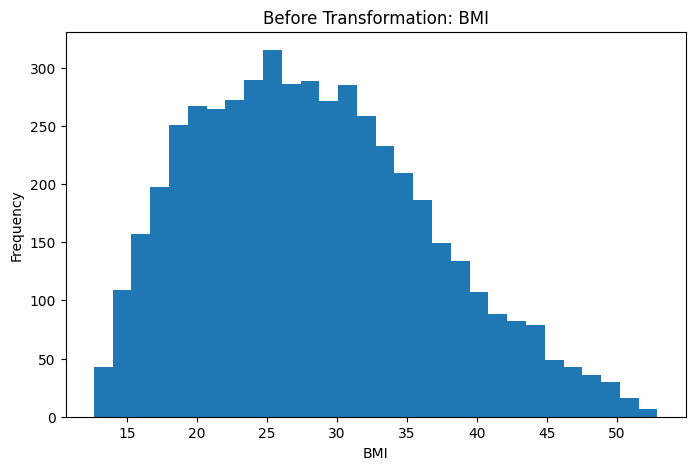

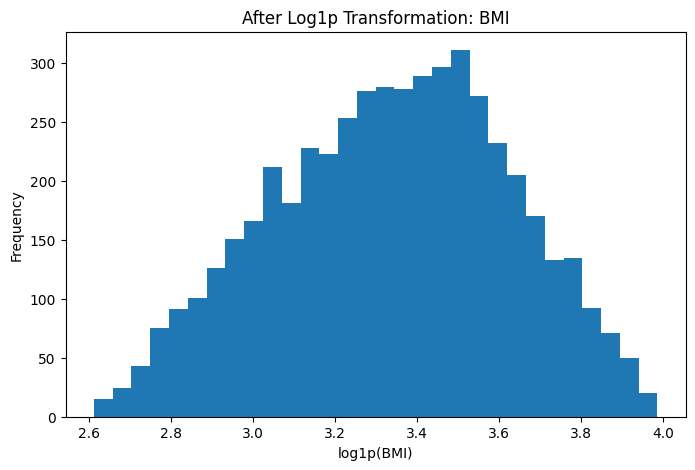

In [18]:
skewness_table = raw_df[predictive_numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False).rename("Skewness").to_frame()
display(skewness_table.round(4))

# Select the most skewed non-negative numerical feature for an explicit before/after demonstration.
nonnegative_candidates = [c for c in predictive_numeric_cols if (raw_df[c] >= 0).all()]
if nonnegative_candidates:
    most_skewed = max(nonnegative_candidates, key=lambda c: abs(raw_df[c].skew()))
    original_skew = raw_df[most_skewed].skew()
    log_values = np.log1p(raw_df[most_skewed])
    transformed_skew = pd.Series(log_values).skew()

    transform_comparison = pd.DataFrame({
        "Feature": [most_skewed],
        "Original Skewness": [original_skew],
        "Log1p Skewness": [transformed_skew],
        "Absolute Skewness Improved": [abs(transformed_skew) < abs(original_skew)]
    })
    display(transform_comparison.round(4))

    plt.figure(figsize=(8,5))
    plt.hist(raw_df[most_skewed], bins=30)
    plt.title(f"Before Transformation: {most_skewed}")
    plt.xlabel(most_skewed)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.hist(log_values, bins=30)
    plt.title(f"After Log1p Transformation: {most_skewed}")
    plt.xlabel(f"log1p({most_skewed})")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No non-negative numerical feature was suitable for a log1p demonstration.")

### Interpretation

The before/after skewness values determine whether the transformation actually reduced asymmetry. If the absolute skewness becomes smaller, the transformation improved symmetry according to this diagnostic; if not, there is no reason to force that transformation into the final pipeline.

# PART H – FEATURE SCALING

## Task H1 – Min-Max Normalization

### Formula

`X′ = (X − Xmin) / (Xmax − Xmin)`

The result is generally in the interval `[0, 1]` when the same minimum and maximum are used.

In [19]:
scale_demo = predictive_numeric_cols[0]
min_value = manual_min(raw_df[scale_demo])
max_value = manual_max(raw_df[scale_demo])

if max_value == min_value:
    normalized = pd.Series(np.zeros(len(raw_df)))
else:
    normalized = (raw_df[scale_demo] - min_value) / (max_value - min_value)

normalization_demo = pd.DataFrame({
    "Original Value": raw_df[scale_demo].head(10).values,
    "Min": min_value,
    "Max": max_value,
    "Normalized Value": normalized.head(10).values
})
display(normalization_demo.round(6))
print("Minimum after normalization:", normalized.min())
print("Maximum after normalization:", normalized.max())

,Original Value,Min,Max,Normalized Value
0,56,18.0,79.0,0.622951
1,69,18.0,79.0,0.836066
2,46,18.0,79.0,0.459016
3,32,18.0,79.0,0.229508
4,60,18.0,79.0,0.688525
5,25,18.0,79.0,0.114754
6,78,18.0,79.0,0.983607
7,38,18.0,79.0,0.327869
8,56,18.0,79.0,0.622951
9,75,18.0,79.0,0.934426


Minimum after normalization: 0.0
Maximum after normalization: 1.0


## Task H2 – Standardization

### Formula

`Z = (X − μ) / σ`

where `μ` is the mean and `σ` is the standard deviation.

In [20]:
mu = manual_mean(raw_df[scale_demo])
sigma = manual_std(raw_df[scale_demo])
if sigma == 0:
    standardized = pd.Series(np.zeros(len(raw_df)))
else:
    standardized = (raw_df[scale_demo] - mu) / sigma

standardization_demo = pd.DataFrame({
    "Original Value": raw_df[scale_demo].head(10).values,
    "Standardized Value": standardized.head(10).values
})
display(standardization_demo.round(6))
print("Mean after standardization:", standardized.mean())
print("Population SD after standardization:", standardized.std(ddof=0))

,Original Value,Standardized Value
0,56,0.401805
1,69,1.127851
2,46,-0.156692
3,32,-0.938588
4,60,0.625204
5,25,-1.329536
6,78,1.630498
7,38,-0.603489
8,56,0.401805
9,75,1.462949


Mean after standardization: 9.237055564881302e-17
Population SD after standardization: 1.0


### Normalization vs Standardization

| Aspect | Min-Max Normalization | Standardization |
|---|---|---|
| Main formula | `(X−Xmin)/(Xmax−Xmin)` | `(X−μ)/σ` |
| Typical scale | 0 to 1 | Mean 0, SD 1 |
| Uses | min and max | mean and standard deviation |
| Sensitivity | Sensitive to extreme min/max values | Can be affected by extreme values through mean/SD |
| Useful when | bounded scale is desirable | features need comparable standardized scale |

The final ML pipeline learns scaling parameters from the **training set only**.

# PART I – DATA VISUALIZATION

## Visualization 1 – Histogram

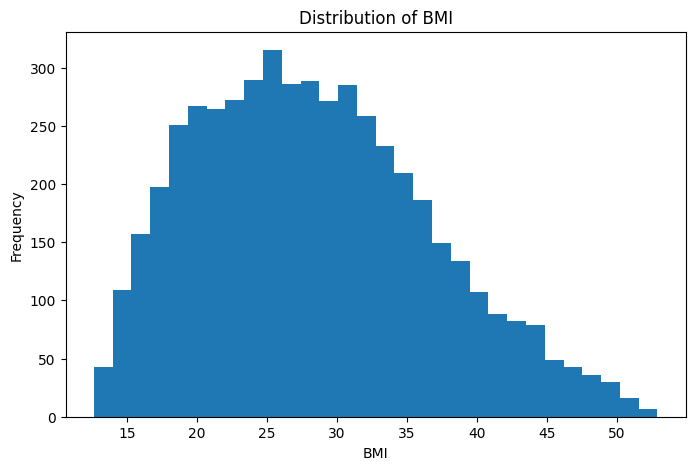

In [21]:
plt.figure(figsize=(8,5))
plt.hist(raw_df["BMI"], bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** This histogram shows the central concentration, spread and possible skewness of BMI values. The exact shape should be read from the displayed dataset distribution rather than assumed beforehand.

## Visualization 2 – Box Plot

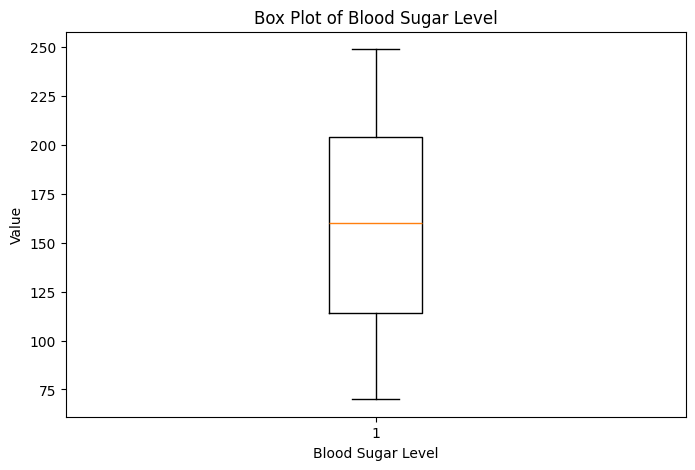

In [22]:
plt.figure(figsize=(8,5))
plt.boxplot(raw_df["Blood_Sugar_Level"].dropna())
plt.title("Box Plot of Blood Sugar Level")
plt.xlabel("Blood Sugar Level")
plt.ylabel("Value")
plt.show()

**Interpretation:** The box plot shows the median, quartile spread and potential extreme observations for blood sugar level. It complements the numerical IQR analysis.

## Visualization 3 – Bar Chart

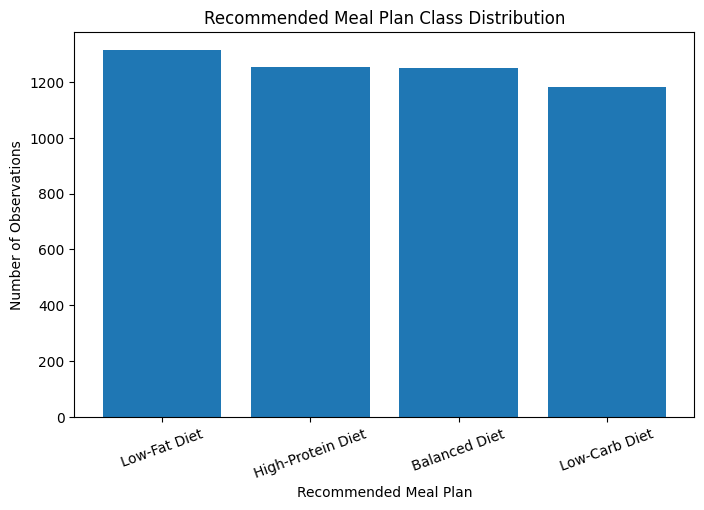

In [23]:
class_counts = raw_df[TARGET].value_counts()
plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Recommended Meal Plan Class Distribution")
plt.xlabel("Recommended Meal Plan")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)
plt.show()

**Interpretation:** The bar chart shows how frequently each target class occurs. This helps identify whether the classification target is roughly balanced or dominated by one class.

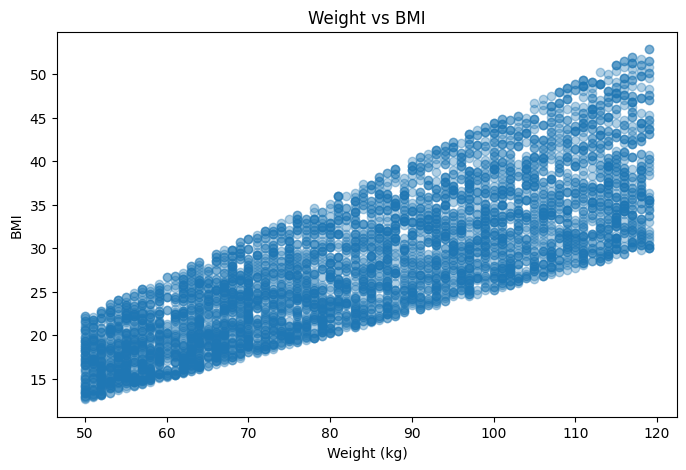

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(raw_df["Weight_kg"], raw_df["BMI"], alpha=0.35)
plt.title("Weight vs BMI")
plt.xlabel("Weight (kg)")
plt.ylabel("BMI")
plt.show()

**Interpretation:** The scatter plot shows the relationship between weight and BMI. A visible trend suggests association, while spread around the trend shows that weight alone does not fully determine BMI.

## Visualization 5 – Correlation Heatmap

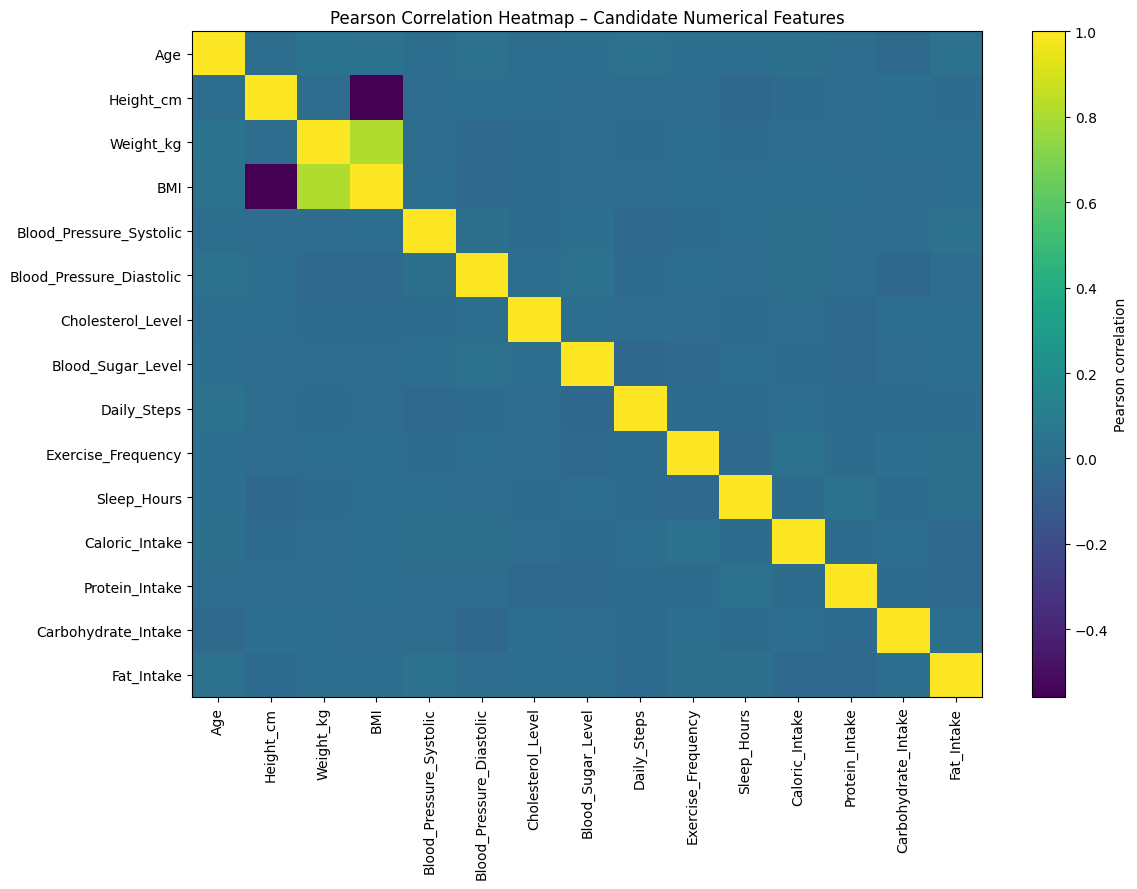

In [25]:
correlation_matrix = raw_df[predictive_numeric_cols].corr()
plt.figure(figsize=(12,9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Pearson Correlation Heatmap – Candidate Numerical Features")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap helps identify numerical feature pairs with strong positive or negative linear association. Strongly correlated predictors may contain redundant information, although correlation alone does not prove that either feature should be removed.

# PART J – TRAIN-TEST SPLIT

## Why split the data?

The model must learn from one subset and be evaluated on observations that were not used during learning. Otherwise, evaluation can be overly optimistic.

An **80/20** split is used here, as allowed by the assignment.

In [26]:
def manual_train_test_split(frame, test_size=0.20, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(len(frame))
    rng.shuffle(indices)
    test_count = int(round(len(frame) * test_size))
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]
    return frame.iloc[train_indices].reset_index(drop=True), frame.iloc[test_indices].reset_index(drop=True)

# Exact duplicates are removed only if they exist; this is non-learned cleaning.
model_base = raw_df.drop_duplicates().reset_index(drop=True)
train_raw, test_raw = manual_train_test_split(model_base, test_size=0.20, random_state=RANDOM_STATE)

split_table = pd.DataFrame({
    "Dataset Part": ["Full Modeling Data", "Training", "Testing"],
    "Rows": [len(model_base), len(train_raw), len(test_raw)],
    "Percentage": [100, 100*len(train_raw)/len(model_base), 100*len(test_raw)/len(model_base)]
})
display(split_table)

,Dataset Part,Rows,Percentage
0,Full Modeling Data,5000,100.0
1,Training,4000,80.0
2,Testing,1000,20.0


### Answers

1. **Why divide the data?** To estimate how the trained model performs on unseen observations.  
2. **Why not use the same observations for final evaluation?** Reusing training observations can make performance look better than it will be on new data.  
3. **Role of randomization:** It prevents row order from determining which observations enter the training or test set and makes the split reproducible when a fixed seed is used.

# PART K – DATA LEAKAGE

## Leakage-Safe From-Scratch Preprocessing Code

In [27]:
def fit_preprocessor(train_df, numeric_features, categorical_features):
    params = {"numeric": {}, "categorical": {}}

    # Numerical parameters are learned from training data only.
    for c in numeric_features:
        params["numeric"][c] = {
            "median": manual_median(train_df[c]),
            "mean": manual_mean(train_df[c]),
            "std": manual_std(train_df[c]),
            "min": manual_min(train_df[c]),
            "max": manual_max(train_df[c])
        }

    # Category vocabulary is learned from training data only.
    for c in categorical_features:
        clean = train_df[c].fillna("Unknown/Not Reported").astype(str)
        params["categorical"][c] = sorted(clean.unique())

    return params


def transform_preprocessor(frame, params, numeric_features, categorical_features, scaling="standard"):
    num_out = pd.DataFrame(index=frame.index)

    for c in numeric_features:
        s = frame[c].fillna(params["numeric"][c]["median"]).astype(float)
        if scaling == "standard":
            mu = params["numeric"][c]["mean"]
            sd = params["numeric"][c]["std"]
            if sd == 0:
                num_out[c] = 0.0
            else:
                num_out[c] = (s - mu) / sd
        elif scaling == "minmax":
            mn = params["numeric"][c]["min"]
            mx = params["numeric"][c]["max"]
            if mx == mn:
                num_out[c] = 0.0
            else:
                num_out[c] = (s - mn) / (mx - mn)
        else:
            num_out[c] = s

    cat_out = pd.DataFrame(index=frame.index)
    for c in categorical_features:
        s = frame[c].fillna("Unknown/Not Reported").astype(str)
        for category in params["categorical"][c]:
            cat_out[f"{c}_{category}"] = (s == category).astype(int)

    return pd.concat([num_out, cat_out], axis=1)

all_params = fit_preprocessor(train_raw, predictive_numeric_cols, predictive_categorical_cols)
X_train_all = transform_preprocessor(train_raw, all_params, predictive_numeric_cols, predictive_categorical_cols, scaling="standard")
X_test_all = transform_preprocessor(test_raw, all_params, predictive_numeric_cols, predictive_categorical_cols, scaling="standard")
X_test_all = X_test_all.reindex(columns=X_train_all.columns, fill_value=0)

y_train = train_raw[TARGET].copy()
y_test = test_raw[TARGET].copy()

print("Training matrix shape:", X_train_all.shape)
print("Testing matrix shape:", X_test_all.shape)
print("Any training NaN:", int(X_train_all.isna().sum().sum()))
print("Any testing NaN:", int(X_test_all.isna().sum().sum()))

Training matrix shape: (4000, 45)
Testing matrix shape: (1000, 45)
Any training NaN: 0
Any testing NaN: 0


### Important

The final preprocessing matrix contains only predictive input candidates. `Patient_ID` is excluded as an identifier, and the `Recommended_*` numeric recommendation outputs are excluded from prediction because they can be post-recommendation or target-derived information and therefore create a leakage risk.

# PART M – FEATURE SELECTION: FROM THEORY TO IMPLEMENTATION

## Task M1 – Variance Threshold

### Formula

`Variance(X) = Σ(xi − x̄)² / n`

A zero-variance feature has exactly the same value for every observation and cannot discriminate between observations. Low variance may also indicate limited information, but it should not be removed blindly.

In [28]:
variance_rows = []
for c in predictive_numeric_cols:
    v = manual_variance(train_raw[c])
    variance_rows.append([c, v])

variance_table = pd.DataFrame(variance_rows, columns=["Feature", "Variance"])
zero_variance = set(variance_table.loc[variance_table["Variance"] == 0, "Feature"])
variance_table["Decision"] = np.where(variance_table["Variance"] == 0, "Remove", "Keep for further analysis")
variance_table["Reason"] = np.where(
    variance_table["Variance"] == 0,
    "Zero variance: no discriminatory variation.",
    "Feature varies; variance alone is not sufficient reason to remove it."
)
display(variance_table.sort_values("Variance").round(6))

,Feature,Variance,Decision,Reason
10,Sleep_Hours,2.914455e+00,Keep for further analysis,Feature varies; variance alone is not sufficie...
9,Exercise_Frequency,3.991773e+00,Keep for further analysis,Feature varies; variance alone is not sufficie...
3,BMI,6.876328e+01,Keep for further analysis,Feature varies; variance alone is not sufficie...
1,Height_cm,2.013417e+02,Keep for further analysis,Feature varies; variance alone is not sufficie...
5,Blood_Pressure_Diastolic,2.975124e+02,Keep for further analysis,Feature varies; variance alone is not sufficie...
0,Age,3.200532e+02,Keep for further analysis,Feature varies; variance alone is not sufficie...
2,Weight_kg,4.095832e+02,Keep for further analysis,Feature varies; variance alone is not sufficie...
4,Blood_Pressure_Systolic,6.851205e+02,Keep for further analysis,Feature varies; variance alone is not sufficie...
14,Fat_Intake,1.387684e+03,Keep for further analysis,Feature varies; variance alone is not sufficie...
6,Cholesterol_Level,1.850821e+03,Keep for further analysis,Feature varies; variance alone is not sufficie...


## Task M2 – Pearson Correlation

### Formula

`r = Σ(xi−x̄)(yi−ȳ) / √[Σ(xi−x̄)² × Σ(yi−ȳ)²]`

Pearson correlation measures **linear association between numerical variables**. Because the target is categorical, Pearson is not used as the primary feature-target test here; ANOVA and Chi-Square are used according to feature type.

In [ ]:
def manual_pearson(x, y):
    x = np.asarray(manual_clean_numeric(x), dtype=float)
    y = np.asarray(manual_clean_numeric(y), dtype=float)
    if len(x) != len(y):
        raise ValueError("Pearson inputs must have equal length after missing-value handling.")
    x_bar = x.mean()
    y_bar = y.mean()
    numerator = np.sum((x-x_bar) * (y-y_bar))
    denominator = math.sqrt(np.sum((x-x_bar)**2) * np.sum((y-y_bar)**2))
    return 0.0 if denominator == 0 else numerator / denominator

pearson_rows = []
for i, c1 in enumerate(predictive_numeric_cols):
    for c2 in predictive_numeric_cols[i+1:]:
        r = manual_pearson(train_raw[c1], train_raw[c2])
        pearson_rows.append([c1, c2, r, abs(r)])

pearson_pairs = pd.DataFrame(pearson_rows, columns=["Feature 1", "Feature 2", "Pearson r", "Absolute r"])
pearson_pairs = pearson_pairs.sort_values("Absolute r", ascending=False).reset_index(drop=True)
display(pearson_pairs.head(20).round(4))

if len(pearson_pairs):
    top = pearson_pairs.iloc[0]
    a, b = top["Feature 1"], top["Feature 2"]
    print("Strongest pair:", a, "and", b)
    print("Manual r:", round(top["Pearson r"], 8))
    print("Pandas verification:", round(train_raw[[a,b]].corr().iloc[0,1], 8))

high_corr_pairs = pearson_pairs[pearson_pairs["Absolute r"] >= 0.85]
print("\nPairs with |r| >= 0.85:", len(high_corr_pairs))
display(high_corr_pairs.round(4))

### Interpretation

- Positive `r` means both variables tend to increase together.
- Negative `r` means one tends to increase when the other decreases.
- Values near zero indicate weak linear association.
- Large absolute values indicate strong linear association.
- Highly correlated predictors may be redundant.

A low Pearson value does **not** prove that no relationship exists because the relationship may be nonlinear.

## Task M3 – Chi-Square Feature Selection

### Formulas

`E = (Row Total × Column Total) / Grand Total`  
`χ² = Σ (O − E)² / E`  
`df = (r − 1)(c − 1)`

Use Chi-Square for suitable categorical/discrete feature–categorical target relationships.

In [51]:
def manual_chi_square(feature, target):
    data = pd.DataFrame({
        "feature": feature.fillna("Unknown/Not Reported").astype(str),
        "target": target.astype(str)
    })
    observed = pd.crosstab(data["feature"], data["target"])
    grand_total = observed.values.sum()
    row_totals = observed.sum(axis=1).to_numpy()
    col_totals = observed.sum(axis=0).to_numpy()

    expected = np.zeros(observed.shape, dtype=float)
    contributions = np.zeros(observed.shape, dtype=float)
    for i in range(observed.shape[0]):
        for j in range(observed.shape[1]):
            expected[i,j] = row_totals[i] * col_totals[j] / grand_total
            if expected[i,j] > 0:
                contributions[i,j] = (observed.iloc[i,j] - expected[i,j])**2 / expected[i,j]

    chi_stat = contributions.sum()
    dfree = (observed.shape[0]-1) * (observed.shape[1]-1)
    return chi_stat, dfree, observed, pd.DataFrame(expected, index=observed.index, columns=observed.columns), pd.DataFrame(contributions, index=observed.index, columns=observed.columns)

chi_rows = []
for c in predictive_categorical_cols:
    stat, dfree, observed, expected, contributions = manual_chi_square(train_raw[c], y_train)
    p_value = chi2_contingency(observed)[1]
    chi_rows.append([c, stat, dfree, p_value])

chi_table = pd.DataFrame(chi_rows, columns=["Feature", "Chi-Square", "Degrees of Freedom", "p-value"]).sort_values("p-value")
display(chi_table.round(6))

# Full from-scratch demonstration for the strongest Chi-Square feature.
if len(chi_table):
    demo_feature = chi_table.iloc[0]["Feature"]
    stat, dfree, observed, expected, contributions = manual_chi_square(train_raw[demo_feature], y_train)
    print("Manual demonstration feature:", demo_feature)
    print("\nObserved frequencies:")
    display(observed)
    print("Expected frequencies:")
    display(expected.round(4))
    print("Chi-Square contribution table:")
    display(contributions.round(4))
    print("Manual total Chi-Square:", round(stat, 8))
    print("Degrees of freedom:", dfree)

    scipy_stat, scipy_p, scipy_df, scipy_expected = chi2_contingency(observed)
    print("\nLibrary verification statistic:", round(scipy_stat, 8))
    print("Library verification p-value:", round(scipy_p, 8))
    print("Library verification df:", scipy_df)

,Feature,Chi-Square,Degrees of Freedom,p-value
6,Dietary_Habits,16.104390,9,0.064733
2,Genetic_Risk_Factor,5.519918,3,0.137452
8,Food_Aversions,12.530620,9,0.185020
3,Allergies,10.221066,9,0.332887
7,Preferred_Cuisine,9.117588,9,0.426491
5,Smoking_Habit,2.440681,3,0.486107
0,Gender,4.255137,6,0.642193
1,Chronic_Disease,7.623231,12,0.813837
4,Alcohol_Consumption,0.685563,3,0.876594


Manual demonstration feature: Dietary_Habits

Observed frequencies:


target,Balanced Diet,High-Protein Diet,Low-Carb Diet,Low-Fat Diet
feature,,,,
Keto,203,230,165,206
Regular,512,483,481,536
Vegan,82,105,88,114
Vegetarian,208,177,197,213


Expected frequencies:


target,Balanced Diet,High-Protein Diet,Low-Carb Diet,Low-Fat Diet
feature,,,,
Keto,202.0050,199.9950,187.1310,214.8690
Regular,505.5150,500.4850,468.2930,537.7070
Vegan,97.7362,96.7638,90.5398,103.9602
Vegetarian,199.7438,197.7562,185.0362,212.4638


Chi-Square contribution table:


target,Balanced Diet,High-Protein Diet,Low-Carb Diet,Low-Fat Diet
feature,,,,
Keto,0.0049,4.5016,2.6173,0.3661
Regular,0.0832,0.6109,0.3448,0.0054
Vegan,2.5337,0.7010,0.0712,0.9696
Vegetarian,0.3413,2.1786,0.7735,0.0014


Manual total Chi-Square: 16.1043899
Degrees of freedom: 9

Library verification statistic: 16.1043899
Library verification p-value: 0.0647334
Library verification df: 9


### Interpretation

A small p-value provides evidence against independence between the categorical feature and target under the Chi-Square assumptions. This is evidence of association, not proof of causation.

## Task M4 – ANOVA F-Test

### Formula / Logic

`F = Variance Between Groups / Variance Within Groups`

The manual calculation requires the overall mean, group means, between-group sum of squares, within-group sum of squares, degrees of freedom and F-statistic.

In [49]:
def manual_anova(groups):
    groups = [np.asarray(g, dtype=float) for g in groups if len(g) > 0]
    all_values = np.concatenate(groups)
    overall_mean = all_values.mean()
    k = len(groups)
    n = len(all_values)

    ss_between = sum(len(g) * (g.mean() - overall_mean)**2 for g in groups)
    ss_within = sum(np.sum((g - g.mean())**2) for g in groups)
    df_between = k - 1
    df_within = n - k
    ms_between = ss_between / df_between
    ms_within = ss_within / df_within
    f_stat = ms_between / ms_within if ms_within != 0 else np.inf
    return overall_mean, ss_between, ss_within, df_between, df_within, f_stat

classes = sorted(y_train.unique())
anova_rows = []
for c in predictive_numeric_cols:
    groups = [train_raw.loc[train_raw[TARGET] == cls, c].dropna().to_numpy() for cls in classes]
    overall, ssb, ssw, dfb, dfw, f_stat = manual_anova(groups)
    p_value = f_dist.sf(f_stat, dfb, dfw)
    anova_rows.append([c, overall, ssb, ssw, dfb, dfw, f_stat, p_value])

anova_table = pd.DataFrame(
    anova_rows,
    columns=["Feature", "Overall Mean", "Between SS", "Within SS", "DF Between", "DF Within", "F-statistic", "p-value"]
).sort_values("p-value")
display(anova_table.round(6))

# Detailed manual example for the strongest ANOVA feature.
if len(anova_table):
    demo_anova_feature = anova_table.iloc[0]["Feature"]
    groups = [train_raw.loc[train_raw[TARGET] == cls, demo_anova_feature].dropna().to_numpy() for cls in classes]
    overall, ssb, ssw, dfb, dfw, f_stat = manual_anova(groups)
    group_mean_table = pd.DataFrame({
        "Target Class": classes,
        "Group Mean": [g.mean() for g in groups],
        "Group Size": [len(g) for g in groups]
    })
    print("Manual ANOVA demonstration feature:", demo_anova_feature)
    display(group_mean_table.round(4))
    print("Overall mean:", round(overall, 6))
    print("Between-group SS:", round(ssb, 6))
    print("Within-group SS:", round(ssw, 6))
    print("DF between:", dfb, "DF within:", dfw)
    print("F-statistic:", round(f_stat, 6))

,Feature,Overall Mean,Between SS,Within SS,DF Between,DF Within,F-statistic,p-value
3,BMI,28.362422,7.361950e+02,2.743169e+05,3,3996,3.574740,0.013395
12,Protein_Intake,124.447250,1.711646e+04,7.462060e+06,3,3996,3.055339,0.027279
2,Weight_kg,84.518500,3.240006e+03,1.635093e+06,3,3996,2.639415,0.047879
1,Height_cm,174.366500,8.797727e+02,8.044869e+05,3,3996,1.456652,0.224360
7,Blood_Sugar_Level,159.558750,9.494149e+03,1.083099e+07,3,3996,1.167594,0.320543
4,Blood_Pressure_Systolic,134.016750,1.817935e+03,2.738664e+06,3,3996,0.884187,0.448444
0,Age,48.890250,8.222922e+02,1.279391e+06,3,3996,0.856105,0.463160
14,Fat_Intake,84.413750,2.916271e+03,5.547820e+06,3,3996,0.700180,0.551862
9,Exercise_Frequency,2.968750,7.638880e+00,1.595945e+04,3,3996,0.637552,0.590778
10,Sleep_Hours,7.015500,5.275191e+00,1.165254e+04,3,3996,0.603006,0.613014


Manual ANOVA demonstration feature: BMI


,Target Class,Group Mean,Group Size
0,Balanced Diet,28.8350,1005
1,High-Protein Diet,27.8381,995
2,Low-Carb Diet,28.0169,931
3,Low-Fat Diet,28.7071,1069


Overall mean: 28.362422
Between-group SS: 736.194952
Within-group SS: 274316.920874
DF between: 3 DF within: 3996
F-statistic: 3.57474


### ANOVA assumptions

The F-test is most interpretable when observations are independent, residuals within groups are approximately normal, and group variances are reasonably similar. A relatively high F-statistic means between-group variation is large relative to within-group variation.

## Task M5 – Mutual Information

### Entropy

`H(Y) = −Σ P(y) log₂ P(y)`

### Conditional Entropy

`H(Y|X) = Σx P(x) H(Y|X=x)`

### Mutual Information

`MI(X;Y) = H(Y) − H(Y|X)`

Equivalently:

`MI(X;Y) = Σ P(x,y) log₂[P(x,y)/(P(x)P(y))]`

With `log₂`, MI is measured in **bits**. `MI = 0` indicates independence under the estimated distribution. MI can capture more general dependence than Pearson correlation, including nonlinear dependence.

For continuous variables, exact MI generally requires specialized estimation. Therefore, the manual demonstration below uses suitable categorical/discrete data as required by the assignment.

In [52]:
def manual_entropy(series):
    s = pd.Series(series).fillna("Unknown/Not Reported").astype(str)
    counts = s.value_counts()
    total = counts.sum()
    entropy = 0.0
    for count in counts:
        p = count / total
        if p > 0:
            entropy -= p * math.log2(p)
    return entropy

def manual_mutual_information(x, y):
    x = pd.Series(x).fillna("Unknown/Not Reported").astype(str)
    y = pd.Series(y).astype(str)
    n = len(x)
    px = x.value_counts() / n
    py = y.value_counts() / n
    joint = pd.crosstab(x, y) / n

    mi = 0.0
    for x_value in joint.index:
        for y_value in joint.columns:
            pxy = joint.loc[x_value, y_value]
            if pxy > 0:
                mi += pxy * math.log2(pxy / (px[x_value] * py[y_value]))
    return mi

mi_rows = []
for c in predictive_categorical_cols:
    mi_rows.append([c, manual_entropy(y_train), manual_mutual_information(train_raw[c], y_train)])

mi_table = pd.DataFrame(mi_rows, columns=["Feature", "H(Y)", "Mutual Information (bits)"]).sort_values("Mutual Information (bits)", ascending=False)
display(mi_table.round(6))

# Detailed manual MI demonstration for the highest-MI feature.
if len(mi_table):
    mi_demo_feature = mi_table.iloc[0]["Feature"]
    x = train_raw[mi_demo_feature].fillna("Unknown/Not Reported").astype(str)
    y = y_train.astype(str)
    joint = pd.crosstab(x, y)
    joint_prob = joint / len(x)
    px = x.value_counts() / len(x)
    py = y.value_counts() / len(y)
    contributions = pd.DataFrame(0.0, index=joint.index, columns=joint.columns)
    for xv in joint.index:
        for yv in joint.columns:
            pxy = joint_prob.loc[xv, yv]
            if pxy > 0:
                contributions.loc[xv, yv] = pxy * math.log2(pxy / (px[xv] * py[yv]))

    print("MI demonstration feature:", mi_demo_feature)
    print("Entropy H(Y):", round(manual_entropy(y), 8), "bits")
    print("Joint probability table:")
    display(joint_prob.round(6))
    print("MI contribution table:")
    display(contributions.round(6))
    print("Total MI:", round(contributions.values.sum(), 8), "bits")

,Feature,H(Y),Mutual Information (bits)
6,Dietary_Habits,1.998272,0.002917
8,Food_Aversions,1.998272,0.002233
3,Allergies,1.998272,0.001848
7,Preferred_Cuisine,1.998272,0.001653
1,Chronic_Disease,1.998272,0.001379
2,Genetic_Risk_Factor,1.998272,0.001006
0,Gender,1.998272,0.000765
5,Smoking_Habit,1.998272,0.000437
4,Alcohol_Consumption,1.998272,0.000123


MI demonstration feature: Dietary_Habits
Entropy H(Y): 1.99827245 bits
Joint probability table:


Recommended_Meal_Plan,Balanced Diet,High-Protein Diet,Low-Carb Diet,Low-Fat Diet
Dietary_Habits,,,,
Keto,0.05075,0.05750,0.04125,0.05150
Regular,0.12800,0.12075,0.12025,0.13400
Vegan,0.02050,0.02625,0.02200,0.02850
Vegetarian,0.05200,0.04425,0.04925,0.05325


MI contribution table:


Recommended_Meal_Plan,Balanced Diet,High-Protein Diet,Low-Carb Diet,Low-Fat Diet
Dietary_Habits,,,,
Keto,0.000360,0.011596,-0.007490,-0.003132
Regular,0.002354,-0.006195,0.004645,-0.000615
Vegan,-0.005192,0.003094,-0.000903,0.003791
Vegetarian,0.003039,-0.007079,0.004452,0.000194


Total MI: 0.00291661 bits


## Task M6 – Select the Correct Feature-Selection Technique

In [29]:
technique_comparison = pd.DataFrame([
    ["Variance Threshold", "Numerical", "Not required", "Detect low-variance features"],
    ["Pearson Correlation", "Numerical", "Numerical", "Linear relationship / redundancy"],
    ["Chi-Square", "Categorical/Discrete", "Categorical", "Statistical dependence"],
    ["ANOVA F-Test", "Numerical", "Categorical", "Difference across target groups"],
    ["Mutual Information", "Discrete/Categorical for manual calculation", "Discrete/Categorical", "Shared information / dependence"],
], columns=["Method", "Feature Type", "Target Type", "Main Purpose"])
display(technique_comparison)

,Method,Feature Type,Target Type,Main Purpose
0,Variance Threshold,Numerical,Not required,Detect low-variance features
1,Pearson Correlation,Numerical,Numerical,Linear relationship / redundancy
2,Chi-Square,Categorical/Discrete,Categorical,Statistical dependence
3,ANOVA F-Test,Numerical,Categorical,Difference across target groups
4,Mutual Information,Discrete/Categorical for manual calculation,Discrete/Categorical,Shared information / dependence


## Task M7 – Final Feature Selection Decision

In [53]:
# Build final selection decisions for all predictive original features.
selected_numeric = []
redundant_removed = set()

# Candidate zero-variance features
for c in predictive_numeric_cols:
    if c in zero_variance:
        continue

# Strong correlation redundancy: remove the weaker ANOVA feature from each pair.
for _, row in high_corr_pairs.iterrows():
    a, b = row["Feature 1"], row["Feature 2"]
    if a in zero_variance or b in zero_variance:
        continue
    pa = float(anova_table.loc[anova_table["Feature"] == a, "p-value"].iloc[0])
    pb = float(anova_table.loc[anova_table["Feature"] == b, "p-value"].iloc[0])
    if pa <= pb:
        redundant_removed.add(b)
    else:
        redundant_removed.add(a)

for c in predictive_numeric_cols:
    if c in zero_variance:
        continue
    if c in redundant_removed:
        continue
    p = float(anova_table.loc[anova_table["Feature"] == c, "p-value"].iloc[0])
    if p < 0.05:
        selected_numeric.append(c)

selected_categorical = []
for c in predictive_categorical_cols:
    p = float(chi_table.loc[chi_table["Feature"] == c, "p-value"].iloc[0])
    if p < 0.05:
        selected_categorical.append(c)

if len(mi_table):
    strongest_mi = mi_table.iloc[0]["Feature"]
    if strongest_mi not in selected_categorical:
        selected_categorical.append(strongest_mi)

selected_original_features = selected_numeric + selected_categorical

# Decision table covering every predictive original feature.
decision_rows = []
for c in predictive_numeric_cols:
    var = float(variance_table.loc[variance_table["Feature"] == c, "Variance"].iloc[0])
    anova_p = float(anova_table.loc[anova_table["Feature"] == c, "p-value"].iloc[0])
    corr_reason = ""
    if c in redundant_removed:
        corr_reason = " Removed from a highly correlated pair because the paired feature has stronger/equal ANOVA evidence."
    if c in zero_variance:
        decision, reason = "Remove", "Zero variance."
    elif c in redundant_removed:
        decision, reason = "Remove", "Strong redundancy (|r| >= 0.85)." + corr_reason
    elif c in selected_numeric:
        decision, reason = "Keep", f"ANOVA p={anova_p:.6g} < 0.05 and no zero-variance/redundancy removal."
    else:
        decision, reason = "Remove", f"ANOVA p={anova_p:.6g} >= 0.05 under the stated selection rule."
    decision_rows.append([c, "Numerical", f"Variance={var:.6g}; ANOVA p={anova_p:.6g}", decision, reason])

for c in predictive_categorical_cols:
    chi_p = float(chi_table.loc[chi_table["Feature"] == c, "p-value"].iloc[0])
    mi_score = float(mi_table.loc[mi_table["Feature"] == c, "Mutual Information (bits)"].iloc[0])
    if c in selected_categorical:
        decision, reason = "Keep", f"Chi-Square p={chi_p:.6g} < 0.05 or strongest MI feature (MI={mi_score:.6g} bits)."
    else:
        decision, reason = "Remove", f"Chi-Square p={chi_p:.6g} >= 0.05 and not the strongest MI feature."
    decision_rows.append([c, "Categorical", f"Chi-Square p={chi_p:.6g}; MI={mi_score:.6g} bits", decision, reason])

final_selection_table = pd.DataFrame(
    decision_rows,
    columns=["Feature", "Data Type", "Method Used / Statistic", "Keep/Remove", "Justification"]
)
display(final_selection_table)

print("Selected original features:")
print(selected_original_features)
print("\nRemoved predictive candidates:")
print([c for c in predictive_input_cols if c not in selected_original_features])

,Feature,Data Type,Method Used / Statistic,Keep/Remove,Justification
0,Age,Numerical,Variance=320.053; ANOVA p=0.46316,Remove,ANOVA p=0.46316 >= 0.05 under the stated selec...
1,Height_cm,Numerical,Variance=201.342; ANOVA p=0.22436,Remove,ANOVA p=0.22436 >= 0.05 under the stated selec...
2,Weight_kg,Numerical,Variance=409.583; ANOVA p=0.0478787,Keep,ANOVA p=0.0478787 < 0.05 and no zero-variance/...
3,BMI,Numerical,Variance=68.7633; ANOVA p=0.0133946,Keep,ANOVA p=0.0133946 < 0.05 and no zero-variance/...
4,Blood_Pressure_Systolic,Numerical,Variance=685.12; ANOVA p=0.448444,Remove,ANOVA p=0.448444 >= 0.05 under the stated sele...
5,Blood_Pressure_Diastolic,Numerical,Variance=297.512; ANOVA p=0.901459,Remove,ANOVA p=0.901459 >= 0.05 under the stated sele...
6,Cholesterol_Level,Numerical,Variance=1850.82; ANOVA p=0.86163,Remove,ANOVA p=0.86163 >= 0.05 under the stated selec...
7,Blood_Sugar_Level,Numerical,Variance=2710.12; ANOVA p=0.320543,Remove,ANOVA p=0.320543 >= 0.05 under the stated sele...
8,Daily_Steps,Numerical,Variance=1.38666e+07; ANOVA p=0.950085,Remove,ANOVA p=0.950085 >= 0.05 under the stated sele...
9,Exercise_Frequency,Numerical,Variance=3.99177; ANOVA p=0.590778,Remove,ANOVA p=0.590778 >= 0.05 under the stated sele...


Selected original features:
['Weight_kg', 'BMI', 'Protein_Intake', 'Dietary_Habits']

Removed predictive candidates:
['Age', 'Gender', 'Height_cm', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Caloric_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions']


## Task M8 – Before vs After Feature Selection

In [54]:
feature_stage_table = pd.DataFrame([
    ["Original Dataset", len(raw_df.columns)],
    ["Original Predictors (target excluded)", len(raw_df.columns) - 1],
    ["Predictive Candidates (ID + potential target-derived outputs excluded)", len(predictive_input_cols)],
    ["Selected Original Features", len(selected_original_features)],
    ["Removed Predictive Candidates", len(predictive_input_cols) - len(selected_original_features)]
], columns=["Stage", "Number of Features"])
display(feature_stage_table)

print("Selected Features:")
for i, c in enumerate(selected_original_features, 1):
    print(f"{i}. {c}")

print("\nRemoved Features:")
for i, c in enumerate([c for c in predictive_input_cols if c not in selected_original_features], 1):
    print(f"{i}. {c}")

,Stage,Number of Features
0,Original Dataset,30
1,Original Predictors (target excluded),29
2,Predictive Candidates (ID + potential target-d...,24
3,Selected Original Features,4
4,Removed Predictive Candidates,20


Selected Features:
1. Weight_kg
2. BMI
3. Protein_Intake
4. Dietary_Habits

Removed Features:
1. Age
2. Gender
3. Height_cm
4. Chronic_Disease
5. Blood_Pressure_Systolic
6. Blood_Pressure_Diastolic
7. Cholesterol_Level
8. Blood_Sugar_Level
9. Genetic_Risk_Factor
10. Allergies
11. Daily_Steps
12. Exercise_Frequency
13. Sleep_Hours
14. Alcohol_Consumption
15. Smoking_Habit
16. Caloric_Intake
17. Carbohydrate_Intake
18. Fat_Intake
19. Preferred_Cuisine
20. Food_Aversions


## Apply the Selected Feature Set Without Leakage

In [55]:
selected_params = fit_preprocessor(train_raw, selected_numeric, selected_categorical)
X_train_selected = transform_preprocessor(
    train_raw, selected_params, selected_numeric, selected_categorical, scaling="standard"
)
X_test_selected = transform_preprocessor(
    test_raw, selected_params, selected_numeric, selected_categorical, scaling="standard"
)
X_test_selected = X_test_selected.reindex(columns=X_train_selected.columns, fill_value=0)

print("Selected training matrix:", X_train_selected.shape)
print("Selected testing matrix:", X_test_selected.shape)
print("Same encoded columns:", list(X_train_selected.columns) == list(X_test_selected.columns))

Selected training matrix: (4000, 7)
Selected testing matrix: (1000, 7)
Same encoded columns: True


# PART N – BEFORE VS AFTER PREPROCESSING

In [56]:
# Count raw missing values and exact duplicates.
raw_missing_total = int(raw_df.isna().sum().sum())
raw_duplicate_total = int(raw_df.duplicated().sum())

# After final transformation, all values should be numerical and complete.
after_missing_total = int(X_train_selected.isna().sum().sum() + X_test_selected.isna().sum().sum())

before_after = pd.DataFrame([
    ["Records", len(raw_df), len(model_base)],
    ["Features / columns", len(raw_df.columns), X_train_selected.shape[1]],
    ["Missing Values", raw_missing_total, after_missing_total],
    ["Duplicate Records", raw_duplicate_total, 0],
    ["Categorical Features", len(categorical_cols), 0],
    ["Potential IQR Outlier Flags", int(iqr_table["Number of Detected Outliers"].sum()), "Retained unless proven invalid"],
    ["Selected Original Features", "Not yet selected", len(selected_original_features)]
], columns=["Parameter", "Before", "After"])
display(before_after)

,Parameter,Before,After
0,Records,5000,5000
1,Features / columns,30,7
2,Missing Values,6765,0
3,Duplicate Records,0,0
4,Categorical Features,11,0
5,Potential IQR Outlier Flags,4,Retained unless proven invalid
6,Selected Original Features,Not yet selected,4


### Interpretation

The final matrix is numerical and has no missing values after training-only preprocessing. The original identifier and leakage-risk recommendation outputs are not included in the predictive matrix. Statistical outliers are not automatically deleted because the assignment requires justification before removal.